In [29]:
from sklearn.datasets import make_regression
import numpy as np

In [30]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=11)
# means we are creating a dataset with 4 samples, 1 feature, 1 informative feature, 1 target variable, and some noise added to the data. The random_state parameter is set to 11 to ensure reproducibility of the results.


In [31]:
X


array([[-0.48456513],
       [-2.65331856],
       [-0.286073  ],
       [ 1.74945474]])

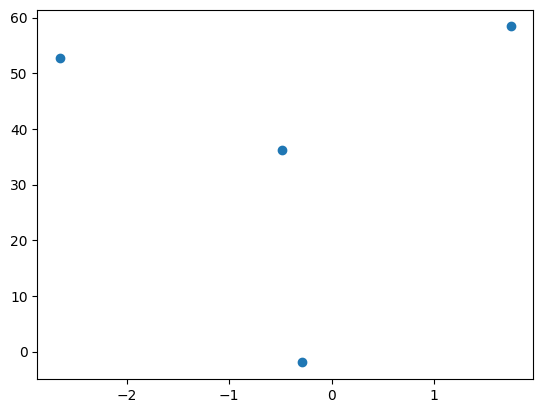

In [32]:

import matplotlib.pyplot as plt
plt.scatter(X,y)
     

<h3>Applying OLS 

In [33]:
from sklearn.linear_model import LinearRegression

In [37]:
lr = LinearRegression()
lr.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
# y_pred = lr.predict(X)

In [39]:
lr.coef_ # slope of the line

array([0.64094324])

In [40]:
lr.intercept_

np.float64(36.58499311283086)

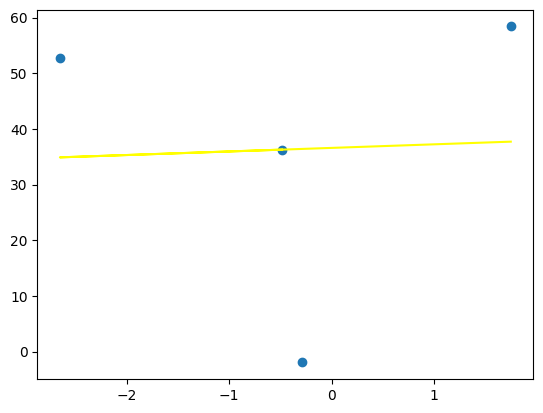

In [41]:
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='yellow')
     

In [42]:
# let's assume slope value is constant and b is 0 ; m = 0.64 and b = 0 

<h4> Here we'll use gradient descent (we have m and b)

In [43]:
y_pred = ((0.64* X) + 100).reshape(4)

In [44]:
y_pred

array([ 99.68987832,  98.30187612,  99.81691328, 101.11965103])

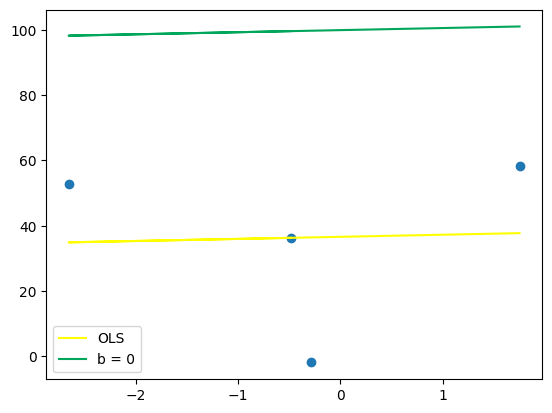

In [45]:
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='yellow',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

In [22]:
# in the above graph we can see that the line with b=0 is not a good fit for the data. 
# The line with b=0 is not able to capture the trend of the data and is not able to minimize the error between 
# the predicted values and the actual values. This is because the line with b=0 is not able to adjust its position to fit the data. 
# The line with b=0 is fixed at a certain position and cannot move up or down to fit the data. 
# This is why we need to find the optimal value of b that minimizes the error between the predicted values and the actual values.

In [49]:
b = 100
m = 0.64
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope
     

np.float64(507.3232139953593)

In [50]:
# let's take learning rate as 0.1

In [51]:
l_r = 0.1

step_size = loss_slope*l_r
step_size

np.float64(50.732321399535934)

In [52]:
b = b - step_size
b

np.float64(49.267678600464066)

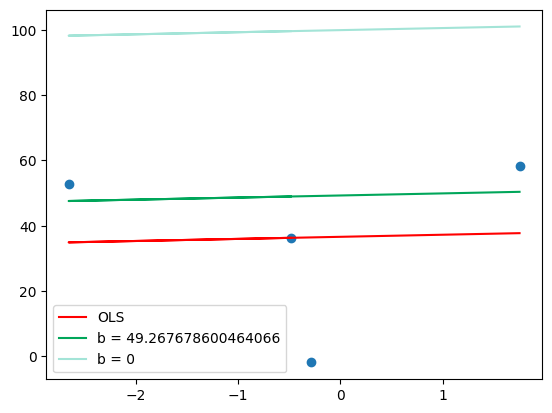

In [53]:
y_pred1 = ((m * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X, lr.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()
     

In [55]:
# again
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

step_size = (loss_slope)*l_r
step_size

b = b - step_size
b
     
loss_slope, step_size, b

(np.float64(20.292928559814357),
 np.float64(2.029292855981436),
 np.float64(37.09192146457544))

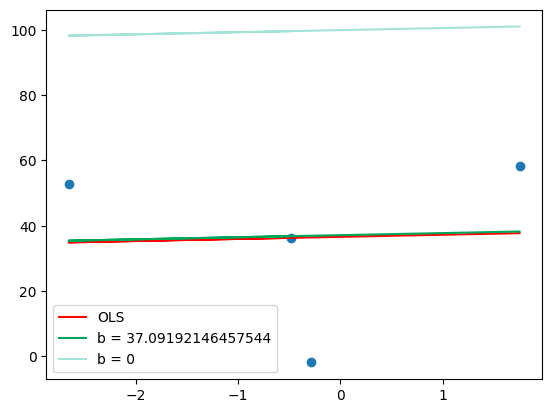

In [56]:
y_pred1 = ((m * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X, lr.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()
     

In [ ]:
# the above convergence we got in two iterations , that is almost optimal
# but it was a small dataset with only 4 samples, if we have a large dataset then it will 
# take more iterations to converge to the optimal value of b.


<h2> Epochs

[[2.61664618]
 [1.22864398]
 [2.74368114]
 [4.04641889]]
[[5.30927261]
 [3.92127041]
 [5.43630757]
 [6.73904533]]
[[7.78648892]
 [6.39848673]
 [7.91352389]
 [9.21626164]]
[[10.06552793]
 [ 8.67752574]
 [10.1925629 ]
 [11.49530065]]
[[12.16224383]
 [10.77424163]
 [12.28927879]
 [13.59201654]]
[[14.09122244]
 [12.70322025]
 [14.21825741]
 [15.52099516]]
[[15.86588277]
 [14.47788058]
 [15.99291774]
 [17.29565549]]
[[17.49857028]
 [16.11056808]
 [17.62560524]
 [18.928343  ]]
[[19.00064278]
 [17.61264059]
 [19.12767775]
 [20.4304155 ]]
[[20.38254948]
 [18.99454729]
 [20.50958445]
 [21.8123222 ]]
[[21.65390365]
 [20.26590146]
 [21.78093862]
 [23.08367637]]
[[22.82354948]
 [21.43554729]
 [22.95058445]
 [24.2533222 ]]
[[23.89962365]
 [22.51162146]
 [24.02665862]
 [25.32939637]]
[[24.88961188]
 [23.50160969]
 [25.01664685]
 [26.3193846 ]]
[[25.80040106]
 [24.41239886]
 [25.92743602]
 [27.23017378]]
[[26.6383271 ]
 [25.25032491]
 [26.76536207]
 [28.06809982]]
[[27.40921906]
 [26.02121686]
 [27.5

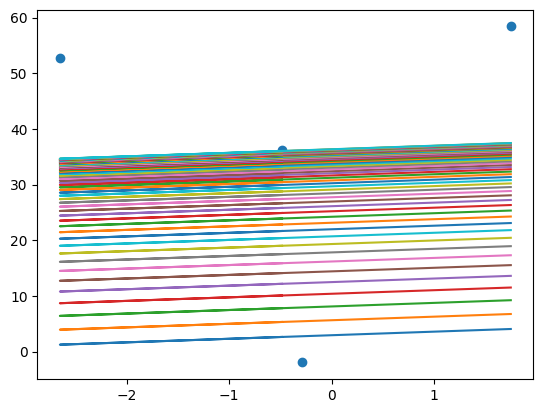

In [65]:
b = 0
m = 0.64
l_r = 0.01  #trying a very small learning rate to see how many iterations it will take to converge to the optimal value of b.

epochs = 60

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (l_r * loss_slope)
  
  y_pred = m * X + b
  print(y_pred)
  plt.plot(X,y_pred)

plt.scatter(X,y)
     